# Data Retrieval

## Configuration

### Setup of environment

In [1]:
# Install required packages for spatial graph embedding pipeline
!pip install geopandas shapely scikit-learn pyogrio fiona rtree osmnx matplotlib


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import math
import json
import warnings
import numpy as np
import pandas as pd
import osmnx as ox
from pathlib import Path

import requests
import geopandas as gpd

import matplotlib.pyplot as plt
import contextily as ctx
from shapely.geometry import box

from shapely.validation import make_valid
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)

In [3]:
# Output Folder
output_dir = Path(r"C:\Users\Diego\PyCharmMiscProject\processed_riga_finale_finale_finale")
output_dir.mkdir(parents=True, exist_ok=True)

### Variable configuration

In [4]:
# # LGIA / WGS84 bounding box
WEST  = 23.93
SOUTH = 56.90
EAST  = 24.16
NORTH = 57.02

# String version for LGIA ArcGIS request
LGIA_BBOX = f"{WEST},{SOUTH},{EAST},{NORTH}"
OSM_BBOX = (WEST, SOUTH, EAST, NORTH)
TARGET_CRS = "EPSG:3059"

LGIA_SERVICES = {
    "land_cover": {
    "base_url": "https://wms.lgia.gov.lv/open/rest/services/INSPIRE/INSPIRE_LC/MapServer",
    "layers": [0],
    "cache_name": "lgia_landcover_single.geojson",
    },
    "terrain": {
        "base_url": "https://wms.lgia.gov.lv/open/rest/services/INSPIRE/INSPIRE_EL/MapServer",
        # 0 = spot elevation, 1 = contour line, 2 = break line
        "layers": [0, 1, 2],
        "cache_name": "lgia_terrain_all.geojson",
    },
    "hydro": {
        "base_url": "https://wms.lgia.gov.lv/open/rest/services/INSPIRE/INSPIRE_HY_PHW/MapServer",
        # Useful hydrography sublayers
        "layers": [2, 3, 5, 8, 11, 12],
        "cache_name": "lgia_hydro_all.geojson",
    },
}

## LGIA retrieval or loading

In [7]:
def query_arcgis_geojson(base_url, layer_id, bbox, in_sr="4326", out_sr="3059", timeout=180):
    url = f"{base_url}/{layer_id}/query"

    # Parameters follow the LGIA ArcGIS REST query structure. Can be found in https://www.lgia.gov.lv/lv/zemes-virsmas-parklajuma-dati-1
    # The bounding box is provided in EPSG:4326 and the output is requested in EPSG:3059.
    params = {
        "where": "1=1",
        "geometry": bbox,
        "geometryType": "esriGeometryEnvelope",
        "inSR": in_sr,
        "spatialRel": "esriSpatialRelIntersects",
        "outFields": "*",
        "returnGeometry": "true",
        "outSR": out_sr,
        "f": "geojson",
    }
    res = requests.get(url, params=params, timeout=timeout)
    res.raise_for_status()

    features = res.json()["features"]
    gdf = gpd.GeoDataFrame.from_features(features, crs=f"EPSG:{out_sr}")
    gdf["source_layer_id"] = layer_id

    return gdf

def load_or_download_lgia(dataset_name, dataset_cfg, output_dir):
    cache_path = output_dir / dataset_cfg["cache_name"]

    # Cached GeoJSON files are stored, in this way data won't be downloaded each time this runs
    # careful, cache files shall be deleted if coords are changed and perform search again
    if cache_path.exists():
        print(f"Loading cache {dataset_name}: {cache_path}")
        return gpd.read_file(cache_path).to_crs(TARGET_CRS)

    frames = []

    # Each selected LGIA layer is downloaded separately and later merged
    # into one GeoDataFrame for the study area.
    for layer_id in dataset_cfg["layers"]:
        print(f"Download in process {dataset_name} layer {layer_id} ...")

        layer_gdf = query_arcgis_geojson(
            base_url=dataset_cfg["base_url"],
            layer_id=layer_id,
            bbox=LGIA_BBOX
        )

        layer_gdf["source_dataset"] = dataset_name
        frames.append(layer_gdf)

    gdf = gpd.GeoDataFrame(
        pd.concat(frames, ignore_index=True),
        geometry="geometry",
        crs=TARGET_CRS
    )

    # Identical geometries are filtered and then removed to avoid duplicated spatial entities
    # in the graph construction stage.
    before = len(gdf)
    gdf["_geom_wkb"] = gdf.geometry.apply(lambda geom: geom.wkb)
    gdf = gdf.drop_duplicates(subset="_geom_wkb").drop(columns="_geom_wkb")

    print(f"{dataset_name}: removed {before - len(gdf)} duplicated geometries ({before} -> {len(gdf)})")

    # The merged dataset is saved as GeoJSON and reused in later notebook runs.
    gdf.to_file(cache_path, driver="GeoJSON")
    print(f"Saved {dataset_name} to: {cache_path}")

    return gdf

In [8]:
landcover_raw = load_or_download_lgia("land_cover", LGIA_SERVICES["land_cover"], output_dir)
terrain_raw   = load_or_download_lgia("terrain",    LGIA_SERVICES["terrain"],    output_dir)
hydro_raw     = load_or_download_lgia("hydro",      LGIA_SERVICES["hydro"],      output_dir)

print("Land cover features:", len(landcover_raw))
print("Terrain features:", len(terrain_raw))
print("Hydro features:", len(hydro_raw))

Loading cached land_cover: C:\Users\Diego\PyCharmMiscProject\processed_riga_finale_finale_finale\lgia_landcover_single.geojson
Loading cached terrain: C:\Users\Diego\PyCharmMiscProject\processed_riga_finale_finale_finale\lgia_terrain_all.geojson
Loading cached hydro: C:\Users\Diego\PyCharmMiscProject\processed_riga_finale_finale_finale\lgia_hydro_all.geojson
Land cover features: 137
Terrain features: 1959
Hydro features: 708


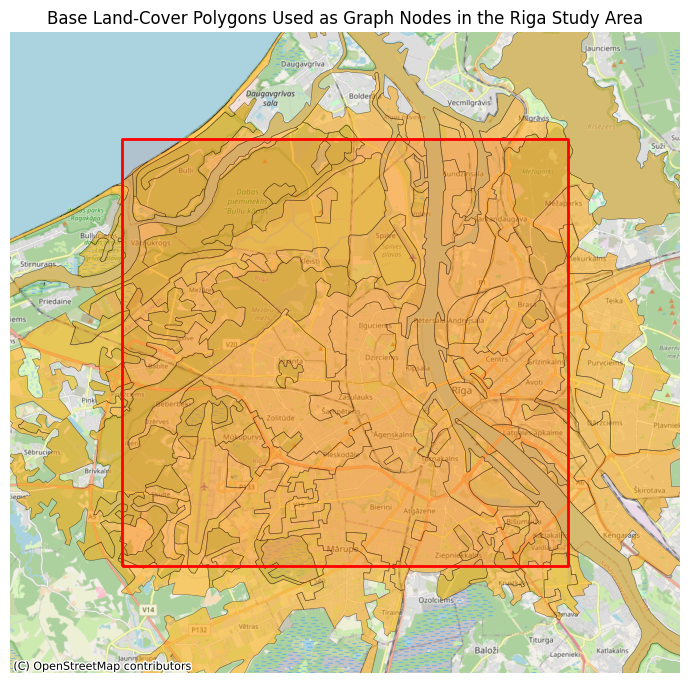

In [247]:
# Map visualization setup
bbox_geom = box(WEST, SOUTH, EAST, NORTH)
bbox_gdf = gpd.GeoDataFrame(
    {"name": ["Study Area"]},
    geometry=[bbox_geom],
    crs="EPSG:4326"
)

base_nodes_gdf = landcover_raw.copy()
# Using this specific epsg because it is only for visualization
bbox_web = bbox_gdf.to_crs(epsg=3857)
base_nodes_web = base_nodes_gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(7, 7))

# Map design considerations
base_nodes_web.plot(ax=ax, color="orange", edgecolor="black", alpha=0.5, linewidth=0.4, label="Land-cover polygons")
bbox_web.plot(ax=ax, facecolor="red", alpha=0.08, edgecolor="red", linewidth=2)
bbox_web.boundary.plot(ax=ax, color="red", linewidth=2, label="Study area bounding box")

minx, miny, maxx, maxy = bbox_web.total_bounds
pad_x = (maxx - minx) * 0.25
pad_y = (maxy - miny) * 0.25

ax.set_xlim(minx - pad_x, maxx + pad_x)
ax.set_ylim(miny - pad_y, maxy + pad_y)

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_title("Base Land-Cover Polygons Used as Graph Nodes in the Riga Study Area")
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Cleaning spatial entities

### Helpers

In [10]:
# For MultiPolygon geometries, the largest polygon is used as the representative shape.
def compactness(area, perimeter):
    return (4 * math.pi * area) / (perimeter ** 2)

def get_representative_polygon(geom):
    return max(geom.geoms, key=lambda g: g.area) if geom.geom_type == "MultiPolygon" else geom

### Cleaning procedure

In [11]:
OUTPUT_DIR = output_dir
TARGET_CRS = "EPSG:3059"
K_NEIGHBORS = 5
OSM_BBOX = (WEST, SOUTH, EAST, NORTH)

In [12]:
print("Loaded land-cover features:", len(landcover_raw))
print("Original CRS:", landcover_raw.crs)

gdf = landcover_raw.copy()

# Geometry is cleaned and projected to EPSG:3059 for metric spatial analysis
gdf["geometry"] = gdf["geometry"].apply(make_valid)
gdf = gdf.to_crs(TARGET_CRS).reset_index(drop=True)

# LGIA class label column is renamed when needed
gdf = gdf.rename(columns={"class_labe": "class_label"})

# Class code is used to derive semantic hierarchy levels.
gdf["class_code_str"] = gdf["class_code"].astype(str)

# Sea/ocean class is excluded in this research because it is not part of land-cover units
gdf = gdf[gdf["class_code_str"] != "523"].reset_index(drop=True)

gdf["node_id"] = np.arange(len(gdf))

gdf["class_lvl1"] = gdf["class_code_str"].str[:1].astype(int)
gdf["class_lvl2"] = gdf["class_code_str"].str[:2].astype(int)
gdf["class_lvl3"] = gdf["class_code_str"].astype(int)

print("After geometry cleaning:", len(gdf))
print("Projected CRS:", gdf.crs)
print(gdf["class_code_str"].value_counts().head(20))

Loaded land-cover features: 137
Original CRS: EPSG:3059
After geometry cleaning: 136
Projected CRS: EPSG:3059
class_code_str
112    19
121    17
312    13
324    10
242    10
141    10
231     8
142     7
411     6
123     6
313     5
412     4
122     4
311     3
331     2
211     2
124     2
512     2
133     2
111     1
Name: count, dtype: int64


In [15]:
# Geometric attributes are calculated in EPSG:3059, so area and distance values are compatible
gdf["area_m2"] = gdf.geometry.area
gdf["perimeter_m"] = gdf.geometry.length

gdf["centroid"] = gdf.geometry.centroid
gdf["centroid_x"] = gdf["centroid"].x
gdf["centroid_y"] = gdf["centroid"].y

gdf["compactness"] = (4 * math.pi * gdf["area_m2"]) / (gdf["perimeter_m"] ** 2)

gdf["bbox_area_m2"] = gdf.geometry.envelope.area

bounds = gdf.geometry.envelope.bounds
bbox_width = bounds["maxx"] - bounds["minx"]
bbox_height = bounds["maxy"] - bounds["miny"]

gdf["elongation_ratio"] = np.maximum(bbox_width, bbox_height) / np.minimum(bbox_width, bbox_height)

In [28]:
gdf["geom_key"] = gdf.geometry.apply(lambda geom: geom.normalize().wkb_hex)

print("Rows after cleaning:", len(gdf))
print("Unique geometries:", gdf["geom_key"].nunique())
print("Duplicated geometry rows:", gdf.duplicated("geom_key").sum())

gdf = gdf.drop(columns="geom_key")

Rows after cleaning: 136
Unique geometries: 136
Duplicated geometry rows: 0


In [29]:
# Hydrographic features are projected to the same CRS as the graph nodes. These attributes describe water intersection, water length, water area, nearest hydro distance and normalized hydro density per polygon.

hydro = hydro_raw.to_crs(gdf.crs)

hydro_lines = hydro[hydro.geometry.geom_type.isin(["LineString", "MultiLineString"])].copy()
hydro_polygons = hydro[hydro.geometry.geom_type.isin(["Polygon", "MultiPolygon"])].copy()

# Binary hydro intersection
hydro_join = gpd.sjoin(
    gdf[["node_id", "geometry"]],
    hydro[["geometry"]],
    how="inner",
    predicate="intersects"
)

gdf["intersects_hydro"] = gdf["node_id"].isin(hydro_join["node_id"]).astype(int)

# Hydro line length inside each polygon
hydro_lines_clip = gpd.overlay(hydro_lines[["geometry"]], gdf[["node_id", "geometry"]], how="intersection")

hydro_line_lengths = (
    hydro_lines_clip.assign(hydro_seg_len_m=hydro_lines_clip.geometry.length)
    .groupby("node_id")["hydro_seg_len_m"]
    .sum()
)

gdf["hydro_length_in_poly_m"] = gdf["node_id"].map(hydro_line_lengths).fillna(0)

# Hydro polygon area inside each land-cover polygon
hydro_poly_clip = gpd.overlay(hydro_polygons[["geometry"]], gdf[["node_id", "geometry"]], how="intersection")

hydro_area = (
    hydro_poly_clip.assign(hydro_area_m2=hydro_poly_clip.geometry.area)
    .groupby("node_id")["hydro_area_m2"]
    .sum()
)

gdf["hydro_area_in_poly_m2"] = gdf["node_id"].map(hydro_area).fillna(0)
gdf["hydro_area_in_poly_m2"] = np.minimum(gdf["hydro_area_in_poly_m2"], gdf["area_m2"])

# Nearest hydro distance from each polygon centroid
centroids_gdf = gpd.GeoDataFrame(gdf[["node_id"]], geometry=gdf.geometry.centroid, crs=gdf.crs)

nearest_hydro = centroids_gdf.sjoin_nearest(hydro[["geometry"]], how="left", distance_col="nearest_hydro_dist_m")

nearest_hydro_dist = (
    nearest_hydro
    .groupby("node_id")["nearest_hydro_dist_m"]
    .min()
)

gdf["nearest_hydro_dist_m"] = gdf["node_id"].map(nearest_hydro_dist)

# Derived hydro density and ratio attributes
gdf["hydro_density_m_per_km2"] = (
    gdf["hydro_length_in_poly_m"] / (gdf["area_m2"] / 1_000_000)
)

gdf["hydro_area_ratio"] = (
    gdf["hydro_area_in_poly_m2"] / gdf["area_m2"]
).clip(0, 1)

print("Hydro enrich complete")
print(gdf[[
    "intersects_hydro",
    "hydro_length_in_poly_m",
    "hydro_area_in_poly_m2",
    "nearest_hydro_dist_m",
    "hydro_density_m_per_km2",
    "hydro_area_ratio"
]].describe())

Hydro enrich complete
       intersects_hydro  hydro_length_in_poly_m  hydro_area_in_poly_m2  \
count        136.000000              136.000000           1.360000e+02   
mean           0.875000             3308.275573           5.212237e+05   
std            0.331942            13648.073970           4.536147e+06   
min            0.000000                0.000000           0.000000e+00   
25%            1.000000               60.252811           0.000000e+00   
50%            1.000000              694.281570           0.000000e+00   
75%            1.000000             2251.435673           1.472550e+04   
max            1.000000           147592.069374           5.046637e+07   

       nearest_hydro_dist_m  hydro_density_m_per_km2  hydro_area_ratio  
count            136.000000               136.000000        136.000000  
mean             284.891935              1539.958505          0.051011  
std              303.104670              1700.195551          0.176394  
min                

In [30]:
# Terrain line features are projected to the same CRS as the graph nodes. This describes terrain line length, nearest terrain distance and terrain line density for each polygon.

terrain = terrain_raw.to_crs(gdf.crs)

terrain_lines = terrain[
    terrain.geometry.geom_type.isin(["LineString", "MultiLineString"])
].copy()

# Terrain line length inside each polygon
terrain_clip = gpd.overlay(
    terrain_lines[["geometry"]],
    gdf[["node_id", "geometry"]],
    how="intersection"
)

terrain_lengths = (
    terrain_clip.assign(terrain_seg_len_m=terrain_clip.geometry.length)
    .groupby("node_id")["terrain_seg_len_m"]
    .sum()
)

gdf["terrain_line_length_in_poly_m"] = (
    gdf["node_id"].map(terrain_lengths).fillna(0)
)

# Nearest terrain line distance from each polygon centroid
nearest_terrain = centroids_gdf.sjoin_nearest(
    terrain_lines[["geometry"]],
    how="left",
    distance_col="nearest_terrain_line_dist_m"
)

nearest_terrain_dist = (
    nearest_terrain.groupby("node_id")["nearest_terrain_line_dist_m"]
    .min()
)

gdf["nearest_terrain_line_dist_m"] = (
    gdf["node_id"].map(nearest_terrain_dist)
)

# Terrain line density normalized by polygon area
gdf["terrain_line_density_m_per_km2"] = (
    gdf["terrain_line_length_in_poly_m"] / (gdf["area_m2"] / 1_000_000)
)

print("Terrain enrichment complete")
print(gdf[[
    "terrain_line_length_in_poly_m",
    "nearest_terrain_line_dist_m",
    "terrain_line_density_m_per_km2"
]].describe())

Terrain enrichment complete
       terrain_line_length_in_poly_m  nearest_terrain_line_dist_m  \
count                     136.000000                   136.000000   
mean                     3834.232844                   518.799483   
std                     12986.743880                   838.518815   
min                         0.000000                     2.893453   
25%                         0.000000                   113.729022   
50%                       643.385428                   283.401043   
75%                      2123.140757                   704.031063   
max                    115328.013415                  8527.040487   

       terrain_line_density_m_per_km2  
count                      136.000000  
mean                      1828.720641  
std                       2531.293961  
min                          0.000000  
25%                          0.000000  
50%                        790.860218  
75%                       2871.192709  
max                      15781

## Geometric feature engineering

## Graph construction

### Adjency Graph

In [31]:
# Adjacency edges are created between polygons that touch each other.
adj_edges = []
sindex = gdf.sindex

for idx, geom in zip(gdf.index, gdf.geometry):
    candidate_indices = [
        j for j in sindex.intersection(geom.bounds)
        if j != idx
    ]

    for j in candidate_indices:
        neighbor_geom = gdf.at[j, "geometry"]

        if geom.touches(neighbor_geom):
            source_id = int(gdf.at[idx, "node_id"])
            target_id = int(gdf.at[j, "node_id"])

            # Keep only one direction at this stage to represent an undirected adjacency relation.
            if source_id < target_id:
                distance_m = gdf.at[idx, "centroid"].distance(gdf.at[j, "centroid"])

                adj_edges.append({
                    "source_id": source_id,
                    "target_id": target_id,
                    "edge_type": "adjacency",
                    "centroid_distance_m": distance_m
                })

adj_df = pd.DataFrame(adj_edges).drop_duplicates()

print("Adjacency edges:", len(adj_df))

Adjacency edges: 314


### kNN Graph

In [32]:
# The first returned neighbor is the node itself, so it is skipped with [1:].
coords = gdf[["centroid_x", "centroid_y"]].to_numpy()

nbrs = NearestNeighbors(n_neighbors=K_NEIGHBORS + 1, metric="euclidean")
nbrs.fit(coords)
distances, indices = nbrs.kneighbors(coords)

knn_edges = []

for i in range(len(gdf)):
    source_id = int(gdf.at[i, "node_id"])
    for dist, j in zip(distances[i][1:], indices[i][1:]):
        target_id = int(gdf.at[j, "node_id"])
        knn_edges.append({
            "source_id": source_id,
            "target_id": target_id,
            "edge_type": "knn",
            "centroid_distance_m": float(dist)
        })

knn_df = pd.DataFrame(knn_edges).drop_duplicates()
print("kNN edges:", len(knn_df))

kNN edges: 680


## Adjency result, kNN Result, Merged result

In [33]:
# Topological attributes came from the adjacency and kNN edge tables.
adj_degree = (
    pd.concat([
        adj_df["source_id"],
        adj_df["target_id"]
    ])
    .value_counts()
    .rename_axis("node_id")
    .reset_index(name="adj_neighbor_count")
)

gdf = gdf.merge(adj_degree, on="node_id", how="left")
gdf["adj_neighbor_count"] = gdf["adj_neighbor_count"].fillna(0).astype(int)

knn_dist_stats = (
    knn_df.groupby("source_id")["centroid_distance_m"]
    .agg(
        knn_mean_dist_m="mean",
        knn_min_dist_m="min",
        knn_max_dist_m="max"
    )
    .reset_index()
    .rename(columns={"source_id": "node_id"})
)

gdf = gdf.merge(knn_dist_stats, on="node_id", how="left")

In [34]:
# Base node and edge tables are exported for later graph construction and training.

node_columns = [
    "node_id",
    "class_code",
    "class_label",
    "area_m2",
    "perimeter_m",
    "centroid_x",
    "centroid_y",
    "compactness",
    "bbox_area_m2",
    "elongation_ratio",
    "adj_neighbor_count",
    "knn_mean_dist_m",
    "knn_min_dist_m",
    "knn_max_dist_m"
]

nodes_df = gdf[node_columns].copy()

nodes_csv = OUTPUT_DIR / "lgia_riga_nodes_base.csv"
adj_csv = OUTPUT_DIR / "lgia_riga_edges_adjacency.csv"
knn_csv = OUTPUT_DIR / "lgia_riga_edges_knn.csv"
geojson_out = OUTPUT_DIR / "lgia_riga_clean.geojson"

nodes_df.to_csv(nodes_csv, index=False)
adj_df.to_csv(adj_csv, index=False)
knn_df.to_csv(knn_csv, index=False)

# GeoJSON is exported in EPSG:4326 for external visualization and inspection.
gdf.drop(columns=["centroid"], errors="ignore").to_crs("EPSG:4326").to_file(
    geojson_out,
    driver="GeoJSON"
)

print("Files saved:")
print(nodes_csv)
print(adj_csv)
print(knn_csv)
print(geojson_out)

print("\nExport summary:")
print("Nodes:", nodes_df.shape)
print("Adjacency edges:", adj_df.shape)
print("kNN edges:", knn_df.shape)

display(nodes_df.head())
display(adj_df.head())
display(knn_df.head())

Files saved:
C:\Users\Diego\PyCharmMiscProject\processed_riga_finale_finale_finale\lgia_riga_nodes_base.csv
C:\Users\Diego\PyCharmMiscProject\processed_riga_finale_finale_finale\lgia_riga_edges_adjacency.csv
C:\Users\Diego\PyCharmMiscProject\processed_riga_finale_finale_finale\lgia_riga_edges_knn.csv
C:\Users\Diego\PyCharmMiscProject\processed_riga_finale_finale_finale\lgia_riga_clean.geojson

Export summary:
Nodes: (136, 14)
Adjacency edges: (314, 4)
kNN edges: (680, 4)


,node_id,class_code,class_label,area_m2,perimeter_m,centroid_x,centroid_y,compactness,bbox_area_m2,elongation_ratio,adj_neighbor_count,knn_mean_dist_m,knn_min_dist_m,knn_max_dist_m
0,0,111,Continuous urban fabric,3.883951e+06,16152.931961,507350.619744,312161.896966,0.187060,8.137702e+06,1.063984,9,1405.283700,606.821561,1762.821708
1,1,112,Discontinuous urban fabric,2.581641e+05,2407.400315,497162.200761,308238.903583,0.559769,4.749896e+05,1.400284,4,662.337983,305.463855,1057.248295
2,2,112,Discontinuous urban fabric,1.186034e+06,8934.240860,500706.192365,308118.406368,0.186720,3.412631e+06,1.005443,4,1546.684436,692.025965,1879.881669
3,3,112,Discontinuous urban fabric,9.945783e+05,7930.565481,508566.564286,306331.614270,0.198720,3.266856e+06,1.609569,6,929.743902,774.915039,1137.306209
4,4,112,Discontinuous urban fabric,4.761137e+05,3466.620407,508032.710463,306974.684168,0.497861,1.021913e+06,1.137787,5,738.173333,462.249749,998.702165


,source_id,target_id,edge_type,centroid_distance_m
0,0,135,adjacency,11558.388842
1,0,44,adjacency,1762.821708
2,0,10,adjacency,2885.068629
3,0,11,adjacency,1307.122650
4,0,9,adjacency,2113.344877


,source_id,target_id,edge_type,centroid_distance_m
0,0,61,knn,606.821561
1,0,11,knn,1307.122650
2,0,26,knn,1616.150940
3,0,59,knn,1733.501642
4,0,44,knn,1762.821708


## OSM enrichment

In [35]:
# OSMnx is configured to reuse downloaded data and query the same Riga bounding box.
ox.settings.use_cache = True
ox.settings.timeout = 180

west, south, east, north = OSM_BBOX

print("OSM bbox:", OSM_BBOX)

OSM bbox: (23.93, 56.9, 24.16, 57.02)


In [37]:
# OSM tag information serves to understand the available tag info inside the selected Riga bounding box.
def extract_osm_tag_info(osm_df, tags_dict):
    tag_info = {}

    for tag in tags_dict:
        values = osm_df[tag].dropna()

        tag_info[tag] = {
            "total_count": len(values),
            "unique_count": values.nunique(),
            "unique_values": sorted(values.unique()),
            "value_counts": values.value_counts().to_dict()
        }

    return tag_info

def split_osm_by_tag(osm_df, tags_dict, target_crs):
    osm_by_tag = {}

    for tag in tags_dict:
        subset = osm_df[osm_df[tag].notna()].copy()
        osm_by_tag[tag] = subset.to_crs(target_crs)

    return osm_by_tag

In [39]:
# tags_all = {
#     "amenity": True,
#     "highway": True,
#     # "building": True,
#     # "landuse": True,
#     # "natural": True,
#     # "shop": True,
#     # "leisure": True,
#     # "tourism": True,
#     # "railway": True,
#     # "office": True,
#     # "man_made": True,
#     # "aeroway": True,
#     # "waterway": True,
#     # "public_transport": True
# }

tags_all = {
    "amenity": True,
    "highway": True,
    "building": True,
    "landuse": True,
    "natural": True,
    "waterway": True,
    "railway": True,
    "public_transport": True,
    "leisure": True,
    "shop": True,
}

# The more tags are include, the more time it wwill take to execute
osm_all = ox.features_from_bbox((west, south, east, north), tags_all)
print("Total features:", len(osm_all))

tag_info = extract_osm_tag_info(osm_all, tags_all)
osm_by_tag = split_osm_by_tag(osm_all, tags_all, target_crs=TARGET_CRS)

Total features: 169119


In [40]:
for tag, info in tag_info.items():
    print(f"\n=== {tag.upper()} ===")
    print("Total:", info["total_count"])
    print("Unique:", info["unique_count"])
    print("Sample types:", info["unique_values"][:10])


=== AMENITY ===
Total: 14728
Unique: 120
Sample types: ['archive', 'arts_centre', 'atm', 'baby_hatch', 'bank', 'bar', 'bbq', 'bench', 'bicycle_parking', 'bicycle_rental']

=== HIGHWAY ===
Total: 62634
Unique: 41
Sample types: ['bus_stop', 'construction', 'corridor', 'crossing', 'cycleway', 'cyclist_waiting_aid', 'elevator', 'footway', 'give_way', 'living_street']

=== BUILDING ===
Total: 40872
Unique: 91
Sample types: ['apartments', 'arbor', 'barn', 'bicycle_shed', 'boathouse', 'bridge', 'bungalow', 'bunker', 'cabin', 'cafe']

=== LANDUSE ===
Total: 13567
Unique: 33
Sample types: ['allotments', 'animal_keeping', 'basin', 'brownfield', 'cemetery', 'civic_admin', 'commercial', 'concrete', 'construction', 'education']

=== NATURAL ===
Total: 26573
Unique: 29
Sample types: ['bay', 'beach', 'bush', 'bush_row', 'cliff', 'coastline', 'depression', 'earth_bank', 'earth_wall', 'grassland']

=== WATERWAY ===
Total: 2177
Unique: 9
Sample types: ['boatyard', 'canal', 'ditch', 'drain', 'fuel', 'ri

In [41]:
osm_amenities = osm_by_tag.get("amenity")
osm_roads = osm_by_tag.get("highway")
osm_buildings = osm_by_tag.get("building")
osm_landuse = osm_by_tag.get("landuse")
osm_natural = osm_by_tag.get("natural")
osm_waterway = osm_by_tag.get("waterway")
osm_railway = osm_by_tag.get("railway")
osm_public_transport = osm_by_tag.get("public_transport")
osm_leisure = osm_by_tag.get("leisure")
osm_shop = osm_by_tag.get("shop")

In [42]:
def add_osm_count_feature(gdf, osm_layer, feature_name, predicate="intersects"):
    gdf[feature_name] = 0

    if osm_layer is None or osm_layer.empty:
        return gdf

    join_df = gpd.sjoin(
        gdf[["node_id", "geometry"]],
        osm_layer[["geometry"]],
        how="left",
        predicate=predicate
    )

    if "index_right" in join_df.columns:
        join_df = join_df[join_df["index_right"].notnull()]

    counts = (
        join_df.groupby("node_id")
        .size()
        .rename(feature_name)
        .reset_index()
    )

    gdf = gdf.drop(columns=[feature_name], errors="ignore").merge(
        counts,
        on="node_id",
        how="left"
    )

    gdf[feature_name] = gdf[feature_name].fillna(0).astype(int)
    return gdf

In [43]:
def add_osm_length_feature(gdf, osm_layer, feature_name):
    gdf[feature_name] = 0.0

    if osm_layer is None or osm_layer.empty:
        return gdf

    line_types = ["LineString", "MultiLineString"]
    osm_lines = osm_layer[osm_layer.geometry.geom_type.isin(line_types)].copy()

    if osm_lines.empty:
        return gdf

    clip_df = gpd.overlay(
        osm_lines[["geometry"]],
        gdf[["node_id", "geometry"]],
        how="intersection"
    )

    clip_df["segment_len_m"] = clip_df.geometry.length

    lengths = (
        clip_df.groupby("node_id")["segment_len_m"]
        .sum()
        .rename(feature_name)
        .reset_index()
    )

    gdf = gdf.drop(columns=[feature_name], errors="ignore").merge(
        lengths,
        on="node_id",
        how="left"
    )

    gdf[feature_name] = gdf[feature_name].fillna(0)
    return gdf

In [44]:
def add_osm_nearest_distance_feature(gdf, osm_layer, feature_name):
    gdf[feature_name] = np.nan

    if osm_layer is None or osm_layer.empty:
        return gdf

    centroids_gdf = gpd.GeoDataFrame(
        gdf[["node_id"]].copy(),
        geometry=gdf["centroid"],
        crs=gdf.crs
    )

    target_gdf = osm_layer[["geometry"]].reset_index(drop=True).copy()

    nearest_join = centroids_gdf.sjoin_nearest(
        target_gdf,
        how="left",
        distance_col=feature_name
    )

    nearest_dist_df = (
        nearest_join.groupby("node_id", as_index=False)[feature_name]
        .min()
    )

    gdf = gdf.drop(columns=[feature_name], errors="ignore").merge(
        nearest_dist_df,
        on="node_id",
        how="left"
    )

    return gdf

In [45]:
gdf = add_osm_count_feature(gdf, osm_buildings, "building_count")
gdf = add_osm_count_feature(gdf, osm_shop, "shop_count")
gdf = add_osm_count_feature(gdf, osm_leisure, "leisure_count")
gdf = add_osm_count_feature(gdf, osm_public_transport, "public_transport_count")

gdf = add_osm_length_feature(gdf, osm_waterway, "waterway_length_in_poly_m")
gdf = add_osm_length_feature(gdf, osm_railway, "railway_length_in_poly_m")

gdf = add_osm_nearest_distance_feature(gdf, osm_waterway, "nearest_waterway_dist_m")
gdf = add_osm_nearest_distance_feature(gdf, osm_railway, "nearest_railway_dist_m")
gdf = add_osm_nearest_distance_feature(gdf, osm_public_transport, "nearest_public_transport_dist_m")
gdf = add_osm_nearest_distance_feature(gdf, osm_shop, "nearest_shop_dist_m")

In [46]:
gdf["building_density_per_km2"] = np.where(
    gdf["area_m2"] > 0,
    gdf["building_count"] / (gdf["area_m2"] / 1_000_000),
    0
)

gdf["shop_density_per_km2"] = np.where(
    gdf["area_m2"] > 0,
    gdf["shop_count"] / (gdf["area_m2"] / 1_000_000),
    0
)

gdf["leisure_density_per_km2"] = np.where(
    gdf["area_m2"] > 0,
    gdf["leisure_count"] / (gdf["area_m2"] / 1_000_000),
    0
)

gdf["waterway_density_m_per_km2"] = np.where(
    gdf["area_m2"] > 0,
    gdf["waterway_length_in_poly_m"] / (gdf["area_m2"] / 1_000_000),
    0
)

gdf["railway_density_m_per_km2"] = np.where(
    gdf["area_m2"] > 0,
    gdf["railway_length_in_poly_m"] / (gdf["area_m2"] / 1_000_000),
    0
)

### Past stuff

In [269]:
# tags_all_amenities = {"amenity": True}
#
# osm_all_amenities = ox.features_from_bbox(
#     (west, south, east, north),
#     tags_all_amenities
# )
#
# print("Total amenity features:", len(osm_all_amenities))
#
# # Unique types
# amenity_types = osm_all_amenities["amenity"].dropna().unique()
#
# print("Total unique amenity types:", len(amenity_types))
# print(sorted(amenity_types))

In [270]:
# tags_all_highways = {"highway": True}
#
# osm_all_roads = ox.features_from_bbox(
#     (west, south, east, north),
#     tags_all_highways
# )
#
# print("Total road features:", len(osm_all_roads))
#
# highway_types = osm_all_roads["highway"].dropna().unique()
#
# print("Total unique highway types:", len(highway_types))
# print(sorted(highway_types))

In [271]:
# tags_amenities = {
#     "amenity": ["school", "hospital", "university", "restaurant"]
# }
# tags_roads = {
#     "highway": ["primary", "secondary", "tertiary", "residential"]
# }
#
# print("Downloading OSM amenities (bbox)...")
# osm_amenities = ox.features_from_bbox((west, south, east, north), tags_amenities)
# print("Amenities downloaded:", len(osm_amenities))
#
# print("Downloading OSM roads (bbox)...")
# osm_roads = ox.features_from_bbox((west, south, east, north), tags_roads)
# print("Roads downloaded:", len(osm_roads))
#
# if not osm_amenities.empty:
#     osm_amenities = osm_amenities.to_crs(TARGET_CRS)
#
# if not osm_roads.empty:
#     osm_roads = osm_roads.to_crs(TARGET_CRS)

### OSM-Derived Features

In [47]:
print("Graph construction summary")
print("Nodes:", len(gdf))
print("Adjacency edges:", len(adj_df))
print("kNN edges:", len(knn_df))
print("Average adjacency degree:", gdf["adj_neighbor_count"].mean())
print(gdf[["knn_mean_dist_m", "knn_min_dist_m", "knn_max_dist_m"]].describe())

Graph construction summary
Nodes: 136
Adjacency edges: 314
kNN edges: 680
Average adjacency degree: 4.617647058823529
       knn_mean_dist_m  knn_min_dist_m  knn_max_dist_m
count       136.000000      136.000000      136.000000
mean       1397.917665      859.072332     1863.168510
std         706.237520      665.301412      783.799139
min         662.337983      106.200492      907.255183
25%        1137.400123      545.901139     1464.866692
50%        1307.719197      793.894845     1786.819759
75%        1496.247871      981.976309     2038.777606
max        8310.227929     7218.134968     9068.400252


In [48]:
gdf["amenity_count"] = 0

amenities_join = gpd.sjoin(
    gdf[["node_id", "geometry"]],
    osm_amenities[["geometry"]],
    how="left",
    predicate="intersects"
)

if "index_right" in amenities_join.columns:
    amenities_join = amenities_join[amenities_join["index_right"].notnull()]

amenity_counts = (
    amenities_join.groupby("node_id")
    .size()
    .rename("amenity_count")
    .reset_index()
)

gdf = gdf.drop(columns=["amenity_count"], errors="ignore").merge(
    amenity_counts,
    on="node_id",
    how="left"
)

gdf["amenity_count"] = gdf["amenity_count"].fillna(0).astype(int)
print("Amenity enrichment complete")

gdf["road_length_in_poly_m"] = 0.0

road_line_types = ["LineString", "MultiLineString"]
osm_roads_lines = osm_roads[osm_roads.geometry.geom_type.isin(road_line_types)].copy()

print("Original osm_roads:", len(osm_roads))
print("Linear road geometries kept:", len(osm_roads_lines))

roads_clip = gpd.overlay(
    osm_roads_lines[["geometry"]],
    gdf[["node_id", "geometry"]],
    how="intersection"
)

roads_clip["road_seg_len_m"] = roads_clip.geometry.length

road_lengths = (
    roads_clip.groupby("node_id")["road_seg_len_m"]
    .sum()
    .rename("road_length_in_poly_m")
    .reset_index()
)

gdf = gdf.drop(columns=["road_length_in_poly_m"], errors="ignore").merge(
    road_lengths,
    on="node_id",
    how="left"
)

gdf["road_length_in_poly_m"] = gdf["road_length_in_poly_m"].fillna(0)
print("Road density enrichment complete")

gdf["amenity_density_per_km2"] = np.where(
    gdf["area_m2"] > 0,
    gdf["amenity_count"] / (gdf["area_m2"] / 1_000_000),
    0
)

gdf["road_density_m_per_km2"] = np.where(
    gdf["area_m2"] > 0,
    gdf["road_length_in_poly_m"] / (gdf["area_m2"] / 1_000_000),
    0
)

Amenity enrichment complete
Original osm_roads: 62634
Linear road geometries kept: 53191
Road density enrichment complete


In [49]:
centroids_gdf = gpd.GeoDataFrame(
    gdf[["node_id"]].copy(),
    geometry=gdf["centroid"],
    crs=gdf.crs
)

roads_gdf = osm_roads_lines[["geometry"]].reset_index(drop=True).copy()

nearest_join = centroids_gdf.sjoin_nearest(
    roads_gdf,
    how="left",
    distance_col="nearest_road_dist_m"
)

nearest_dist_df = (
    nearest_join.groupby("node_id", as_index=False)["nearest_road_dist_m"]
    .min()
)

gdf = gdf.drop(columns=["nearest_road_dist_m"], errors="ignore").merge(
    nearest_dist_df,
    on="node_id",
    how="left"
)

print("Nearest road distance computed")
print(gdf["nearest_road_dist_m"].describe())
print("Unique node_id after nearest-road merge:", gdf["node_id"].nunique(), "rows:", len(gdf))

Nearest road distance computed
count     136.000000
mean      186.437622
std       727.379266
min         0.522064
25%        11.215890
50%        40.860200
75%       123.704087
max      8063.275311
Name: nearest_road_dist_m, dtype: float64
Unique node_id after nearest-road merge: 136 rows: 136


In [50]:
print("OSM enrichment summary")
print("Polygons with amenities:", (gdf["amenity_count"] > 0).sum())
print("Polygons with roads:", (gdf["road_length_in_poly_m"] > 0).sum())
print("Missing values per enriched feature:")
print(gdf[[
    "amenity_count",
    "nearest_road_dist_m",
    "road_length_in_poly_m",
    "amenity_density_per_km2",
    "road_density_m_per_km2"
]].isna().sum())

OSM enrichment summary
Polygons with amenities: 136
Polygons with roads: 134
Missing values per enriched feature:
amenity_count              0
nearest_road_dist_m        0
road_length_in_poly_m      0
amenity_density_per_km2    0
road_density_m_per_km2     0
dtype: int64


### Export Enriched Node Table

In [55]:
# Final feature groups used for the enriched node table and later training.

id_cols = [
    "node_id",
    "class_code",
    "class_code_str",
    "class_label"
]

semantic_cols = [
    "class_lvl1",
    "class_lvl2",
    "class_lvl3"
]

geometric_cols = [
    "area_m2",
    "perimeter_m",
    "centroid_x",
    "centroid_y",
    "compactness",
    "bbox_area_m2",
    "elongation_ratio"
]

topological_cols = [
    "adj_neighbor_count",
    "knn_mean_dist_m",
    "knn_min_dist_m",
    "knn_max_dist_m"
]

lgia_hydro_cols = [
    "intersects_hydro",
    "hydro_length_in_poly_m",
    "hydro_area_in_poly_m2",
    "nearest_hydro_dist_m",
    "hydro_density_m_per_km2",
    "hydro_area_ratio"
]

lgia_terrain_cols = [
    "terrain_line_length_in_poly_m",
    "nearest_terrain_line_dist_m",
    "terrain_line_density_m_per_km2"
]

osm_basic_cols = [
    "amenity_count",
    "nearest_road_dist_m",
    "road_length_in_poly_m",
    "amenity_density_per_km2",
    "road_density_m_per_km2"
]

osm_extended_cols = [
    "building_count",
    "shop_count",
    "leisure_count",
    "public_transport_count",
    "waterway_length_in_poly_m",
    "railway_length_in_poly_m",
    "nearest_waterway_dist_m",
    "nearest_railway_dist_m",
    "nearest_public_transport_dist_m",
    "nearest_shop_dist_m",
    "building_density_per_km2",
    "shop_density_per_km2",
    "leisure_density_per_km2",
    "waterway_density_m_per_km2",
    "railway_density_m_per_km2"
]

feature_cols = (
    semantic_cols +
    geometric_cols +
    topological_cols +
    lgia_hydro_cols +
    lgia_terrain_cols +
    osm_basic_cols +
    osm_extended_cols
)

node_columns_extended = id_cols + feature_cols

nodes_df = gdf[node_columns_extended].copy()

nodes_csv_extended = OUTPUT_DIR / "lgia_riga_nodes_enriched_osm.csv"
nodes_df.to_csv(nodes_csv_extended, index=False)

print("Saved:", nodes_csv_extended)
print("Node export shape:", nodes_df.shape)
print("Number of feature columns:", len(feature_cols))
display(nodes_df.head())

Saved: C:\Users\Diego\PyCharmMiscProject\processed_riga_finale_finale_finale\lgia_riga_nodes_enriched_osm.csv
Node export shape: (136, 47)
Number of feature columns: 43


,node_id,class_code,class_code_str,class_label,class_lvl1,class_lvl2,class_lvl3,area_m2,perimeter_m,centroid_x,...,railway_length_in_poly_m,nearest_waterway_dist_m,nearest_railway_dist_m,nearest_public_transport_dist_m,nearest_shop_dist_m,building_density_per_km2,shop_density_per_km2,leisure_density_per_km2,waterway_density_m_per_km2,railway_density_m_per_km2
0,0,111,111,Continuous urban fabric,1,11,111,3.883951e+06,16152.931961,507350.619744,...,23442.855507,488.969557,161.706600,168.051538,35.217971,975.810548,371.271454,42.997457,173.444258,6035.827359
1,1,112,112,Discontinuous urban fabric,1,11,112,2.581641e+05,2407.400315,497162.200761,...,0.000000,165.061064,1810.734860,169.455243,285.887340,182.054748,7.747011,15.494021,0.000000,0.000000
2,2,112,112,Discontinuous urban fabric,1,11,112,1.186034e+06,8934.240860,500706.192365,...,0.000000,317.422920,1722.690325,40.846682,162.317212,322.081914,2.529439,2.529439,1766.454368,0.000000
3,3,112,112,Discontinuous urban fabric,1,11,112,9.945783e+05,7930.565481,508566.564286,...,0.000000,297.778890,1503.199189,371.136880,475.163426,156.850404,7.038159,13.070867,516.351603,0.000000
4,4,112,112,Discontinuous urban fabric,1,11,112,4.761137e+05,3466.620407,508032.710463,...,0.000000,76.433215,1008.670367,208.744956,365.827358,676.309029,2.100339,2.100339,2379.828462,0.000000


## Prepare Embedding Inputs

In [56]:
embed_df = nodes_df.copy()

In [57]:
print(embed_df.head())

   node_id class_code class_code_str                 class_label  class_lvl1  \
0        0        111            111     Continuous urban fabric           1   
1        1        112            112  Discontinuous urban fabric           1   
2        2        112            112  Discontinuous urban fabric           1   
3        3        112            112  Discontinuous urban fabric           1   
4        4        112            112  Discontinuous urban fabric           1   

   class_lvl2  class_lvl3       area_m2   perimeter_m     centroid_x  ...  \
0          11         111  3.883951e+06  16152.931961  507350.619744  ...   
1          11         112  2.581641e+05   2407.400315  497162.200761  ...   
2          11         112  1.186034e+06   8934.240860  500706.192365  ...   
3          11         112  9.945783e+05   7930.565481  508566.564286  ...   
4          11         112  4.761137e+05   3466.620407  508032.710463  ...   

   railway_length_in_poly_m  nearest_waterway_dist_m  ne

In [58]:
# Semantic class mapping is displayed to document the land-cover hierarchy used as part of the feature matrix.
class_mapping = (
    embed_df[["class_code_str", "class_label", "class_lvl1", "class_lvl2", "class_lvl3"]]
    .drop_duplicates()
    .sort_values("class_code_str")
    .reset_index(drop=True)
)

class_counts = (
    embed_df["class_code_str"]
    .value_counts()
    .rename_axis("class_code_str")
    .reset_index(name="node_count")
)

class_mapping = class_mapping.merge(class_counts, on="class_code_str", how="left")

display(class_mapping.head(20))

print("Embedding feature columns:", len(feature_cols))

,class_code_str,class_label,class_lvl1,class_lvl2,class_lvl3,node_count
0,111,Continuous urban fabric,1,11,111,1
1,112,Discontinuous urban fabric,1,11,112,19
2,121,Industrial or commercial units,1,12,121,17
3,122,Road and rail networks and associated land,1,12,122,4
4,123,Port areas,1,12,123,6
5,124,Airports,1,12,124,2
6,131,Mineral extraction sites,1,13,131,1
7,133,Construction sites,1,13,133,2
8,141,Green urban areas,1,14,141,10
9,142,Sport and leisure facilities,1,14,142,7


Embedding feature columns: 43


In [59]:
missing_features = [col for col in feature_cols if col not in embed_df.columns]

if missing_features:
    raise ValueError(f"Missing feature columns: {missing_features}")

X_raw = embed_df[feature_cols].apply(pd.to_numeric, errors="coerce")

null_counts = X_raw.isna().sum()

if null_counts.sum() > 0:
    print("Null values found in final feature matrix:")
    print(null_counts[null_counts > 0])
    X_raw = X_raw.fillna(0)

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print("Feature matrix shape:", X.shape)
print("Number of nodes:", len(embed_df))
print("Number of features:", len(feature_cols))

Feature matrix shape: (136, 43)
Number of nodes: 136
Number of features: 43


### Prepare Edge List

In [60]:
adj_part = adj_df[["source_id", "target_id", "edge_type", "centroid_distance_m"]].copy()
knn_part = knn_df[["source_id", "target_id", "edge_type", "centroid_distance_m"]].copy()

edges_df = (
    pd.concat([adj_part , knn_part], ignore_index=True)
    .drop_duplicates(subset=["source_id", "target_id", "edge_type"])
    .reset_index(drop=True)
)

edges_df["spatial_weight"] = 1.0 / (1.0 + edges_df["centroid_distance_m"])

print(edges_df.head())
print("Number of merged edges:", len(edges_df))

edges_rev = edges_df.rename(
    columns={"source_id": "target_id", "target_id": "source_id"}
).copy()

edges_undirected = pd.concat([edges_df, edges_rev], ignore_index=True)
edges_undirected = (
    edges_undirected[
        ["source_id", "target_id", "edge_type", "centroid_distance_m", "spatial_weight"]
    ]
    .drop_duplicates(subset=["source_id", "target_id", "edge_type"])
    .reset_index(drop=True)
)

print(edges_undirected.head())
print("Symmetric directed edge entries:", len(edges_undirected))

   source_id  target_id  edge_type  centroid_distance_m  spatial_weight
0          0        135  adjacency         11558.388842        0.000087
1          0         44  adjacency          1762.821708        0.000567
2          0         10  adjacency          2885.068629        0.000346
3          0         11  adjacency          1307.122650        0.000764
4          0          9  adjacency          2113.344877        0.000473
Number of merged edges: 994
   source_id  target_id  edge_type  centroid_distance_m  spatial_weight
0          0        135  adjacency         11558.388842        0.000087
1          0         44  adjacency          1762.821708        0.000567
2          0         10  adjacency          2885.068629        0.000346
3          0         11  adjacency          1307.122650        0.000764
4          0          9  adjacency          2113.344877        0.000473
Symmetric directed edge entries: 1456


### Save Processed Embedding Outputs

In [61]:
X_df = pd.DataFrame(X, columns=[f"f_{i}" for i in range(X.shape[1])])
X_df.insert(0, "node_id", embed_df["node_id"].values)

feature_matrix_csv = os.path.join(OUTPUT_DIR, "embedding_feature_matrix.csv")
edge_list_csv = os.path.join(OUTPUT_DIR, "embedding_edge_list.csv")
class_map_csv = os.path.join(OUTPUT_DIR, "embedding_class_mapping.csv")

edge_list_export = edges_undirected.rename(
    columns={"source_id": "source", "target_id": "target"}
)

X_df.to_csv(feature_matrix_csv, index=False)
edge_list_export.to_csv(edge_list_csv, index=False)
class_mapping.to_csv(class_map_csv, index=False)

print("Saved:", feature_matrix_csv)
print("Saved:", edge_list_csv)
print("Saved:", class_map_csv)

Saved: C:\Users\Diego\PyCharmMiscProject\processed_riga_finale_finale_finale\embedding_feature_matrix.csv
Saved: C:\Users\Diego\PyCharmMiscProject\processed_riga_finale_finale_finale\embedding_edge_list.csv
Saved: C:\Users\Diego\PyCharmMiscProject\processed_riga_finale_finale_finale\embedding_class_mapping.csv


## Reproductibility

In [62]:
metadata = {
    "target_crs": TARGET_CRS,
    "k_neighbors": K_NEIGHBORS,
    "bbox_wgs84": {
        "west": WEST,
        "south": SOUTH,
        "east": EAST,
        "north": NORTH
    },
    "feature_columns": feature_cols,
    "edge_columns": ["source", "target", "edge_type", "centroid_distance_m", "spatial_weight"],
    "num_edges_merged": int(len(edges_df)),
    "num_edge_entries_symmetric": int(len(edges_undirected)),
    "num_nodes": int(len(embed_df)),
    "num_features": int(len(feature_cols)),
    "num_lgia_landcover_raw": int(len(landcover_raw)),
    "num_lgia_landcover_cleaned": int(len(gdf)),
    "num_adjacency_edges": int(len(adj_df)),
    "num_knn_edges": int(len(knn_df))
}

metadata_path = os.path.join(OUTPUT_DIR, "embedding_metadata.json")
with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Saved:", metadata_path)

Saved: C:\Users\Diego\PyCharmMiscProject\processed_riga_finale_finale_finale\embedding_metadata.json
